```markdown
# CYBERNETIC PLANT — AI-DRIVEN HEALTH OPTIMIZATION
## STEP 1: DATA LOADING, TRAINING & SAVING
```

In [1]:
# ── INSTALL LIBRARIES ────────────────────────────────────────
!pip install kaggle xgboost -q

In [2]:
# ── IMPORTS ────────────────────────────────────────────────
import os
import zipfile
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive, files
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

In [3]:
# ── 1. MOUNT DRIVE ───────────────────────────────────────────
drive.mount('/content/drive')
BASE = "/content/drive/MyDrive/plant_health_project"
os.makedirs(BASE, exist_ok=True)
print("✅ Drive mounted. Folder ready:", BASE)

Mounted at /content/drive
✅ Drive mounted. Folder ready: /content/drive/MyDrive/plant_health_project


```markdown
## 2. DOWNLOAD DATASET FROM KAGGLE

First, upload your `kaggle.json` file. You can generate one from your Kaggle account settings.
```

In [4]:
os.makedirs("/root/.kaggle", exist_ok=True)
print("\n📂 Upload your kaggle.json file:")
files.upload()
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json


📂 Upload your kaggle.json file:


Saving kaggle.json to kaggle.json


In [5]:
# Download the dataset
os.system(f"kaggle datasets download -d ziya07/plant-health-data -p {BASE}")

# Safe extraction using Python (avoids shell -q flag issue)
zip_path = f"{BASE}/plant-health-data.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    print("📦 Files inside zip:", z.namelist())
    z.extractall(BASE)
print("✅ Dataset downloaded and extracted.")

📦 Files inside zip: ['plant_health_data.csv']
✅ Dataset downloaded and extracted.


```markdown
## 3. LOAD DATA

Now, let's load the data from the extracted CSV file into a pandas DataFrame.
```

In [14]:
# Auto-detect CSV to handle any filename capitalisation variation
csv_files = [f for f in os.listdir(BASE) if f.endswith(".csv")]
if not csv_files:
    raise FileNotFoundError("❌ No CSV found after extraction. Check zip contents above.")

# Find the actual plant health data CSV, ensuring it's not the feature_columns.csv
data_csv = None
for f in csv_files:
    if "plant_health_data" in f.lower(): # Case-insensitive search
        data_csv = f
        break

if data_csv is None:
    raise FileNotFoundError("❌ 'plant_health_data.csv' not found after extraction.")

DATA_PATH = f"{BASE}/{data_csv}"
print(f"\n📄 Loading: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

print(f"\n📊 Dataset Shape : {df.shape}")
print(f"📋 Columns       : {df.columns.tolist()}")
display(df.head())


📄 Loading: /content/drive/MyDrive/plant_health_project/plant_health_data.csv

📊 Dataset Shape : (1200, 14)
📋 Columns       : ['Timestamp', 'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status']


,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


```markdown
## 4. FEATURE ENGINEERING

Here, we will create new features from existing ones and handle the target encoding.
```

In [16]:
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.sort_values("Timestamp").reset_index(drop=True)

    # Time features
    df['hour']        = df['Timestamp'].dt.hour
    df['day']         = df['Timestamp'].dt.day
    df['month']       = df['Timestamp'].dt.month
    df['day_of_week'] = df['Timestamp'].dt.dayofweek
else:
    print("⚠️ Timestamp column not found or already dropped — skipping time features")

# Interaction features - adding checks to prevent KeyError
if 'Ambient_Temperature' in df.columns and 'Soil_Temperature' in df.columns:
    df['temp_diff'] = df['Ambient_Temperature'] - df['Soil_Temperature']
else:
    print("⚠️ Missing 'Ambient_Temperature' or 'Soil_Temperature' for 'temp_diff'")

if 'Soil_Moisture' in df.columns and 'Soil_pH' in df.columns:
    df['moisture_x_ph'] = df['Soil_Moisture'] * df['Soil_pH']
else:
    print("⚠️ Missing 'Soil_Moisture' or 'Soil_pH' for 'moisture_x_ph'")

if 'Nitrogen_Level' in df.columns and 'Phosphorus_Level' in df.columns and 'Potassium_Level' in df.columns:
    df['npk_total'] = df['Nitrogen_Level'] + df['Phosphorus_Level'] + df['Potassium_Level']
else:
    print("⚠️ Missing NPK levels for 'npk_total'")

if 'Ambient_Temperature' in df.columns and 'Soil_Moisture' in df.columns:
    df['stress_index'] = df['Ambient_Temperature'] / (df['Soil_Moisture'] + 1)
else:
    print("⚠️ Missing 'Ambient_Temperature' or 'Soil_Moisture' for 'stress_index'")

if 'Light_Intensity' in df.columns and 'Humidity' in df.columns:
    df['light_per_humid'] = df['Light_Intensity'] / (df['Humidity'] + 1)
else:
    print("⚠️ Missing 'Light_Intensity' or 'Humidity' for 'light_per_humid'")

if 'Chlorophyll_Content' in df.columns and 'Light_Intensity' in df.columns:
    df['chloro_x_light'] = df['Chlorophyll_Content'] * df['Light_Intensity']
else:
    print("⚠️ Missing 'Chlorophyll_Content' or 'Light_Intensity' for 'chloro_x_light'")

if 'Soil_pH' in df.columns and 'Soil_Moisture' in df.columns:
    df['ph_x_moisture'] = df['Soil_pH'] * df['Soil_Moisture']
else:
    print("⚠️ Missing 'Soil_pH' or 'Soil_Moisture' for 'ph_x_moisture'")

# Drop non-feature columns
df = df.drop([col for col in ["Timestamp", "Plant_ID"] if col in df.columns], axis=1, errors='ignore')

# Encode target
# Check if 'Plant_Health_Status' column exists and is of object type
if 'Plant_Health_Status' in df.columns and df['Plant_Health_Status'].dtype == object:
    encoder = LabelEncoder()
    df['Plant_Health_Status'] = encoder.fit_transform(df['Plant_Health_Status'])
elif 'Plant_Health_Status' in df.columns:
    print("⚠️ Target already encoded — skipping")
else:
    print("⚠️ 'Plant_Health_Status' column not found for encoding.")

In [15]:
print(df.columns.tolist())

['Timestamp', 'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status']


```markdown
## 5. TRAIN / TEST SPLIT (time-aware)

We'll split the data into training and testing sets, ensuring a time-aware split.
```

In [17]:
if 'Plant_Health_Status' not in df.columns:
    print("❌ Error: 'Plant_Health_Status' column not found in DataFrame for split.")
    print("Current columns in df:", df.columns.tolist())
    raise KeyError("'Plant_Health_Status' column missing.")

split   = int(len(df) * 0.8)
X_train = df.iloc[:split].drop("Plant_Health_Status", axis=1)
y_train = df.iloc[:split]["Plant_Health_Status"]
X_test  = df.iloc[split:].drop("Plant_Health_Status", axis=1)
y_test  = df.iloc[split:]["Plant_Health_Status"]

print(f"\n📐 Train samples : {len(X_train)}")
print(f"📐 Test  samples : {len(X_test)}")
print(f"📐 Features      : {X_train.columns.tolist()}")


📐 Train samples : 960
📐 Test  samples : 240
📐 Features      : ['Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'hour', 'day', 'month', 'day_of_week', 'temp_diff', 'moisture_x_ph', 'npk_total', 'stress_index', 'light_per_humid', 'chloro_x_light', 'ph_x_moisture']


```markdown
## 6. TRAIN XGBoost MODEL

Now, let's train an XGBoost Classifier model.
```

In [18]:
print("\n⏳ Training XGBoost model...")

model = XGBClassifier(
    n_estimators          = 1000,
    max_depth             = 6,
    learning_rate         = 0.01,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 1,
    gamma                 = 0,
    reg_alpha             = 0.1,
    reg_lambda            = 1,
    objective             = 'multi:softprob',
    num_class             = len(encoder.classes_) if 'encoder' in locals() else 3, # Default to 3 if encoder not defined
    eval_metric           = 'mlogloss',
    early_stopping_rounds = 50,
    random_state          = 42,
    n_jobs                = -1,
    verbosity             = 0,
)

model.fit(
    X_train, y_train,
    eval_set = [(X_test, y_test)],
    verbose  = 200,
)


⏳ Training XGBoost model...
[0]	validation_0-mlogloss:1.06817
[200]	validation_0-mlogloss:0.15621
[400]	validation_0-mlogloss:0.03845
[600]	validation_0-mlogloss:0.01660
[800]	validation_0-mlogloss:0.01169
[969]	validation_0-mlogloss:0.01138


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=0,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=-1, num_class=3, ...)

```markdown
## 7. EVALUATE MODEL

Let's evaluate the trained model's performance using accuracy, classification report, confusion matrix, and feature importance.
```

In [19]:
preds = model.predict(X_test)
acc   = accuracy_score(y_test, preds)

print(f"\n{'='*50}")
print(f"  ✅ FINAL ACCURACY ON REAL TEST DATA : {acc*100:.2f}%")
print(f"{'-'*50}")
if 'encoder' in locals():
    print(classification_report(y_test, preds, target_names=encoder.classes_))
else:
    print(classification_report(y_test, preds))


  ✅ FINAL ACCURACY ON REAL TEST DATA : 99.58%
--------------------------------------------------
                 precision    recall  f1-score   support

        Healthy       1.00      0.98      0.99        60
    High Stress       1.00      1.00      1.00        96
Moderate Stress       0.99      1.00      0.99        84

       accuracy                           1.00       240
      macro avg       1.00      0.99      1.00       240
   weighted avg       1.00      1.00      1.00       240



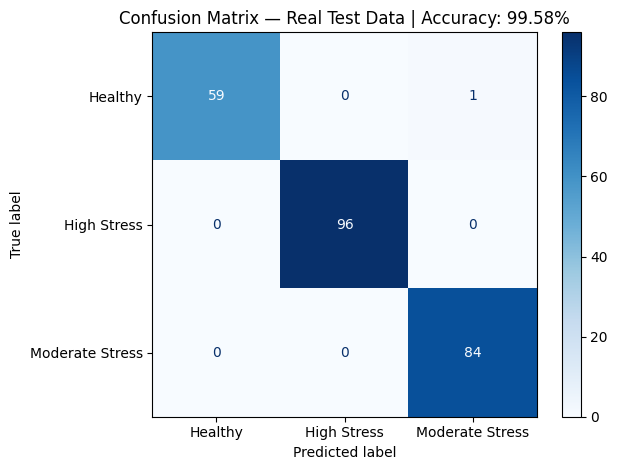

In [20]:
# Confusion Matrix
if 'encoder' in locals():
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels = encoder.classes_,
        cmap           = 'Blues',
    )
else:
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        cmap           = 'Blues',
    )
plt.title(f"Confusion Matrix — Real Test Data | Accuracy: {acc*100:.2f}%")
plt.tight_layout()
plt.show()

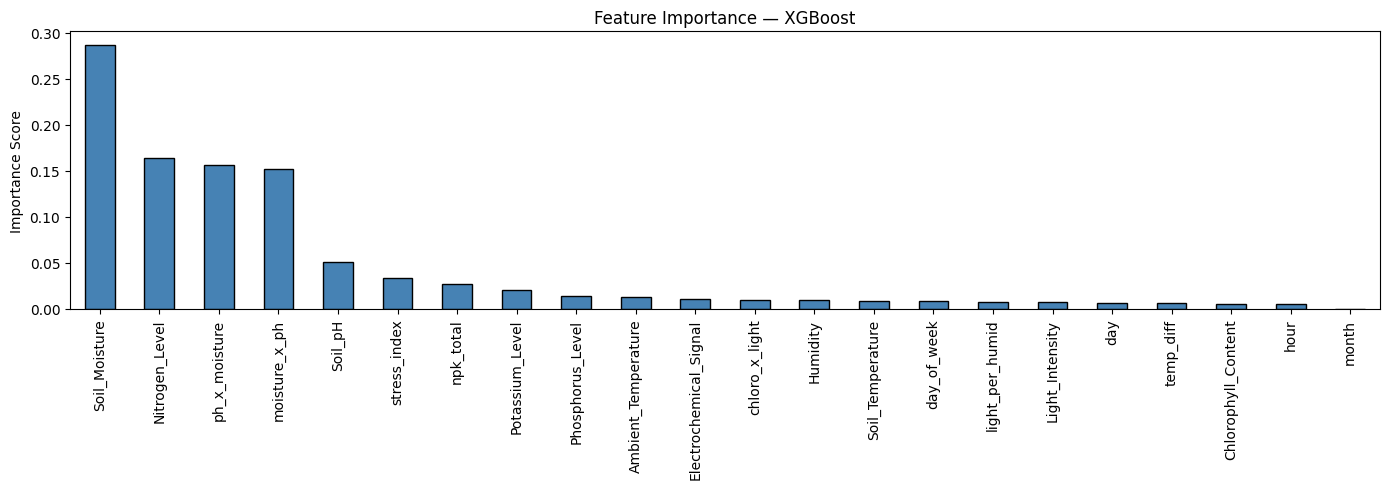

In [21]:
# Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=False).plot(
    kind      = 'bar',
    figsize   = (14, 5),
    color     = 'steelblue',
    edgecolor = 'black',
)
plt.title("Feature Importance — XGBoost")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

```markdown
## 8. SAVE MODEL + ENCODER + FEATURE COLUMNS

Finally, we will save the trained model, the LabelEncoder, and the list of feature columns for future use.
```

In [22]:
joblib.dump(model,   f"{BASE}/plant_health_model.pkl")
if 'encoder' in locals():
    joblib.dump(encoder, f"{BASE}/plant_health_encoder.pkl")
pd.Series(X_train.columns.tolist()).to_csv(
    f"{BASE}/feature_columns.csv", index=False
)

print("✅ Model saved     →", f"{BASE}/plant_health_model.pkl")
if 'encoder' in locals():
    print("✅ Encoder saved   →", f"{BASE}/plant_health_encoder.pkl")
print("✅ Features saved  →", f"{BASE}/feature_columns.csv")

✅ Model saved     → /content/drive/MyDrive/plant_health_project/plant_health_model.pkl
✅ Encoder saved   → /content/drive/MyDrive/plant_health_project/plant_health_encoder.pkl
✅ Features saved  → /content/drive/MyDrive/plant_health_project/feature_columns.csv


```markdown
🎉 STEP 1 COMPLETE — Now run Step 2 for dummy data testing.
```

✅ Model loaded.
🏷️  Classes  : ['Healthy', 'High Stress', 'Moderate Stress']
📋 Features : 22

📂 Test file  : /content/drive/MyDrive/plant_health_project/test/dummy_test_data.csv
📊 Shape      : (600, 14)

🌿 Class Distribution:
Plant_Health_Status
Healthy            223
Moderate Stress    211
High Stress        166
Name: count, dtype: int64



,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2025-03-01 00:00:00,PLT3732,21.187173,17.685219,18.351310,55.646891,405.503491,6.022314,19.759482,34.216874,27.890871,15.000000,0.200000,Moderate Stress
1,2025-03-01 06:00:00,PLT4264,36.410290,33.184771,21.803634,40.189088,734.321218,6.800573,44.131692,38.296997,30.508067,23.398574,0.866984,Healthy
2,2025-03-01 12:00:00,PLT5859,19.256298,22.233754,21.791616,66.636892,612.838037,7.268399,16.128211,26.411072,24.909859,33.623270,1.204874,Moderate Stress
3,2025-03-01 18:00:00,PLT8891,24.050751,24.104876,22.377983,80.214464,787.328647,5.846692,27.263828,27.447577,7.746150,33.670809,1.323068,Moderate Stress
4,2025-03-02 00:00:00,PLT5373,26.366051,25.687476,19.689549,41.154552,349.213945,6.639046,5.000000,41.023163,28.980445,63.914207,2.349848,High Stress



✅ Preprocessing done. Predicting on 600 samples ...

  ✅ TEST ACCURACY : 92.50%

📋 Classification Report:

                 precision    recall  f1-score   support

        Healthy       0.94      0.96      0.95       223
    High Stress       0.92      0.95      0.94       166
Moderate Stress       0.91      0.87      0.89       211

       accuracy                           0.93       600
      macro avg       0.92      0.93      0.93       600
   weighted avg       0.92      0.93      0.92       600



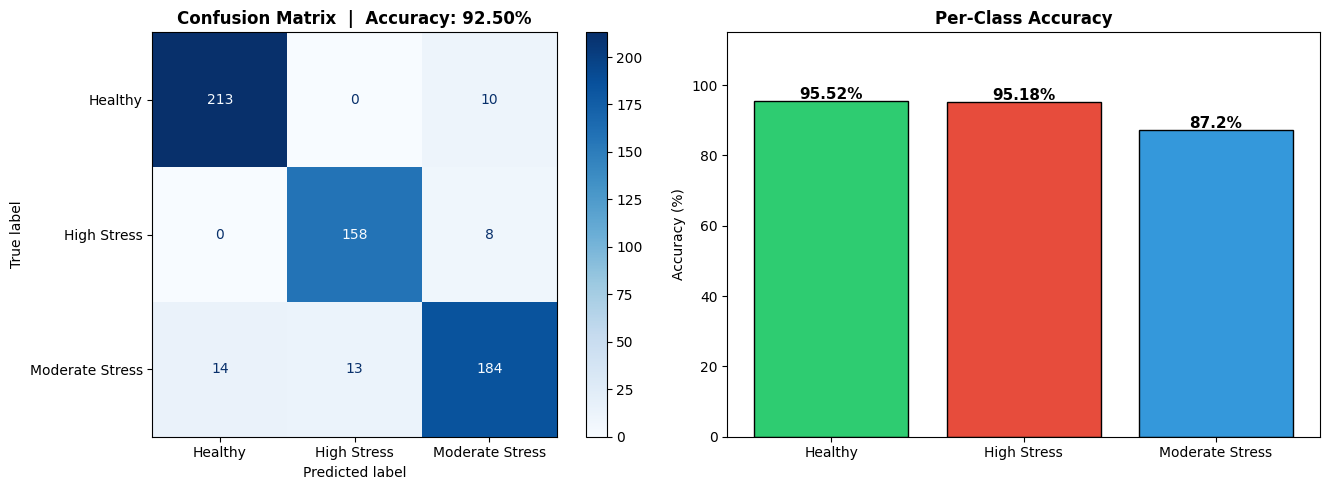


🔍 Sample Predictions (first 15 rows):


,Soil_Moisture,Ambient_Temperature,Humidity,Soil_pH,npk_total,Actual,Predicted,Correct
0,21.187173,17.685219,55.646891,6.022314,81.867227,Moderate Stress,Moderate Stress,True
1,36.410290,33.184771,40.189088,6.800573,112.936756,Healthy,Healthy,True
2,19.256298,22.233754,66.636892,7.268399,67.449142,Moderate Stress,High Stress,False
3,24.050751,24.104876,80.214464,5.846692,62.457555,Moderate Stress,Moderate Stress,True
4,26.366051,25.687476,41.154552,6.639046,75.003608,High Stress,High Stress,True
5,34.431377,19.674723,54.868001,7.214106,81.132579,Healthy,Healthy,True
6,23.875647,17.310889,65.947624,5.043491,68.742651,Moderate Stress,Moderate Stress,True
7,22.585406,26.219914,58.862329,5.494083,71.294911,Moderate Stress,Moderate Stress,True
8,42.859772,24.984617,51.590276,6.980468,89.447846,Healthy,Healthy,True
9,19.991019,21.165518,38.116784,6.046280,113.572712,High Stress,High Stress,True



📊 Total Samples : 600
✅ Correct       : 555  (92.50%)
❌ Wrong         : 45  (7.50%)

🎉 STEP 2B COMPLETE.


In [28]:
# -*- coding: utf-8 -*-
"""
╔══════════════════════════════════════════════════════════╗
║   CYBERNETIC PLANT — AI-DRIVEN HEALTH OPTIMIZATION      ║
║   STEP 2B : LOAD DUMMY TEST DATA & EVALUATE MODEL       ║
╚══════════════════════════════════════════════════════════╝
  Loads dummy_test_data.csv from the test folder and
  evaluates the saved XGBoost model.
"""

import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# ── 1. MOUNT DRIVE ───────────────────────────────────────────
BASE     = "/content/drive/MyDrive/plant_health_project"
TEST_DIR = f"{BASE}/test"

# ── 2. LOAD MODEL + ENCODER + FEATURES ──────────────────────
model    = joblib.load(f"{BASE}/plant_health_model.pkl")
encoder  = joblib.load(f"{BASE}/plant_health_encoder.pkl")
features = pd.read_csv(f"{BASE}/feature_columns.csv").iloc[:, 0].tolist()

print("✅ Model loaded.")
print(f"🏷️  Classes  : {list(encoder.classes_)}")
print(f"📋 Features : {len(features)}\n")

# ── 3. LOAD DUMMY TEST DATASET ───────────────────────────────
TEST_PATH = f"{TEST_DIR}/dummy_test_data.csv"

if not os.path.exists(TEST_PATH):
    raise FileNotFoundError(
        f"❌ Dummy test file not found at:\n   {TEST_PATH}\n"
        "   Please run STEP 2A first to generate it."
    )

df = pd.read_csv(TEST_PATH)

print(f"📂 Test file  : {TEST_PATH}")
print(f"📊 Shape      : {df.shape}")
print(f"\n🌿 Class Distribution:")
print(df['Plant_Health_Status'].value_counts())
print()
display(df.head(5))

# ── 4. PREPROCESS (same pipeline as STEP 1 training) ────────
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values("Timestamp").reset_index(drop=True)

# Time features
df['hour']        = df['Timestamp'].dt.hour
df['day']         = df['Timestamp'].dt.day
df['month']       = df['Timestamp'].dt.month
df['day_of_week'] = df['Timestamp'].dt.dayofweek

# Interaction features
df['temp_diff']       = df['Ambient_Temperature'] - df['Soil_Temperature']
df['moisture_x_ph']   = df['Soil_Moisture'] * df['Soil_pH']
df['npk_total']       = df['Nitrogen_Level'] + df['Phosphorus_Level'] + df['Potassium_Level']
df['stress_index']    = df['Ambient_Temperature'] / (df['Soil_Moisture'] + 1)
df['light_per_humid'] = df['Light_Intensity'] / (df['Humidity'] + 1)
df['chloro_x_light']  = df['Chlorophyll_Content'] * df['Light_Intensity']
df['ph_x_moisture']   = df['Soil_pH'] * df['Soil_Moisture']

# Encode target
df['Plant_Health_Status'] = encoder.transform(df['Plant_Health_Status'])

X_test = df[features]
y_test = df['Plant_Health_Status']

print(f"\n✅ Preprocessing done. Predicting on {len(X_test)} samples ...")

# ── 5. PREDICT ───────────────────────────────────────────────
preds = model.predict(X_test)
acc   = accuracy_score(y_test, preds)

print(f"\n{'='*50}")
print(f"  ✅ TEST ACCURACY : {acc*100:.2f}%")
print(f"{'='*50}\n")

# ── 6. CLASSIFICATION REPORT ─────────────────────────────────
print("📋 Classification Report:\n")
print(classification_report(y_test, preds, target_names=encoder.classes_))

# ── 7. CONFUSION MATRIX + PER-CLASS ACCURACY ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, preds,
    display_labels = encoder.classes_,
    cmap           = 'Blues',
    ax             = axes[0],
)
axes[0].set_title(
    f"Confusion Matrix  |  Accuracy: {acc*100:.2f}%",
    fontsize=12, fontweight='bold'
)

# Per-class accuracy bar chart
cls_accs = {}
for i, cls in enumerate(encoder.classes_):
    mask = y_test == i
    cls_accs[cls] = round(accuracy_score(y_test[mask], preds[mask]) * 100, 2)

bars = axes[1].bar(
    cls_accs.keys(), cls_accs.values(),
    color     = ['#2ecc71', '#e74c3c', '#3498db'],
    edgecolor = 'black',
)
for bar, val in zip(bars, cls_accs.values()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val}%", ha='center', fontweight='bold', fontsize=11,
    )
axes[1].set_ylim(0, 115)
axes[1].set_title("Per-Class Accuracy", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Accuracy (%)")

plt.tight_layout()
plt.show()

# ── 8. SAMPLE PREDICTIONS TABLE ──────────────────────────────
results = df[['Soil_Moisture', 'Ambient_Temperature',
              'Humidity', 'Soil_pH', 'npk_total']].copy()
results['Actual']    = encoder.inverse_transform(y_test)
results['Predicted'] = encoder.inverse_transform(preds)
results['Correct']   = results['Actual'] == results['Predicted']

print("\n🔍 Sample Predictions (first 15 rows):")
display(results.head(15))

correct = results['Correct'].sum()
wrong   = len(results) - correct
print(f"\n📊 Total Samples : {len(results)}")
print(f"✅ Correct       : {correct}  ({correct/len(results)*100:.2f}%)")
print(f"❌ Wrong         : {wrong}  ({wrong/len(results)*100:.2f}%)")
print("\n🎉 STEP 2B COMPLETE.")